# Análisis de Absentismo Laboral - RRHH (13-JUL-2026)

---

### Preguntas de negocio

> Cómo influyen  en los niveles de absentismo los factores de:
- el consumo social de alcohol
- el consumo social de tabaco 
- los antecedentes disciplinarios

 > Cómo podríamos diseñar acciones preventivas y culturales para promover un entorno laboral más saludable y minimizar el impacto del absentismo?
 ---


### Antecedente:

En la semana anterior se desarrolló un modelo de regresión logística binaria, en el que la variable dependiente clasificaba a los empleados según pertenecieran o no al grupo de alto absentismo.
Resultados: sólo `Disciplinary Failure` salió estadísticamente significativa y con una alta probabilidad (aprox. 10%) de que, controlando el resto de variables, un miembro que sí tenga una falta disciplinaria forme parte del grupo de **absentismo alto**. Los resultados de las otras 2 variables de interés de esta semana fueron que el consumo social de alcohol y tabaco no mostraron una asociación estadísticamente significativa tras ajustar por el resto de variables:

- consumo social de **alcohol**: OR = 1,84 pero p-valor = 0,442*
- consumo social de **tabaco**: OR = 1,94 pero p-valor = 0,328*

*No se podía asegurar que los resultados no se debieran al azar en los registros de los empleados analizados.

---

### Pasos

1. La variable dependiente deja de ser binaria y pasa a representarse mediante tres categorías ordinales (bajo, medio y alto absentismo).
2. Ajustar un modelo de regresión logística ordinal dado que la variable dependiente del análisis multivariante deja de ser binario (si el empleado forma parte de la categoría alto_absentismo o no).
3. Evaluar el efectos de las 3 variables sobre la probabilidad de pertenecer a uno los grupos de absentismo medida mediante odds ratios e intervalos de confianza.

### Justificación metodológica

Variables involucradas:
- Total 

### Metodología:

1. **Agregación por empleado.** Los registros del dataset son solicitudes de ausencia, no empleados individuales. Se agregan a nivel de persona (x empleados), para garantizar la independencia de las observaciones.


## 1. Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np

import os
from dotenv import load_dotenv

## 2. Carga de datos <span style="color: red;">(CAMBIAR NAME CSV  Y TABLA mysql)</span>

In [3]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_07072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-06.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos de la base de datos cargados correctamente desde MySQL.'

## 3. Preparación del dataset

### 3.1 Agregación por empleado

- Las horas de absentismo se agregan mediante **suma** (el total acumulado del período). 
- Las variables personales y sociodemográficas estables a lo largo del tiempo se conservan con el **primer valor** (first) registrado.
- Las variables que pueden variar entre episodios (carga de trabajo, hit target) se resumen con la **media**.

In [4]:
df_modelo = (
    df
    .groupby("ID_Employee")
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),

        # Variables personales
        Age=("Age", "first"),
        Education=("Education", "first"),
        Son=("Son", "first"),
        Social_Drinker=("Social_Drinker", "max"),
        Social_Smoker=("Social_Smoker", "max"),
        Pet=("Pet", "first"),
        Body_Mass_Index=("Body_Mass_Index", "first"),

        # Variables laborales
        Service_Time=("Service_Time", "first"),
        Transportation_Expense=("Transportation_Expense", "mean"),
        Distance_Residence_Work=("Distance_Residence_Work", "first"),
        Work_load_Average_Day=("Work_load_Average_Day", "mean"),
        Hit_Target=("Hit_Target", "mean"),
        Disciplinary_Failure=("Disciplinary_Failure", "max")
    )
    .reset_index()
)

In [5]:

umbral_alto = df_modelo["Total_Horas_Absentismo"].quantile(0.75)

df_modelo["Absentismo_Alto"] = (
    df_modelo["Total_Horas_Absentismo"] >= umbral_alto
).astype(int)

print("Umbral de absentismo alto:", umbral_alto)
print(df_modelo["Absentismo_Alto"].value_counts())

Umbral de absentismo alto: 21.75
Absentismo_Alto
0    102
1     34
Name: count, dtype: int64


## 4. Análisis bivariante

Antes del modelo multivariable, se compara cada variable entre los dos grupos: empleados con absentismo alto (Absentismo_Alto = 1) y el resto (Absentismo_Alto = 0). El objetivo es identificar qué variables presentan diferencias relevantes entre grupos.

Se usan tests no paramétricos porque la distribución de las horas sigue siendo asimétrica tras la agregación:
- **Spearman**: variables numéricas continuas
- **Mann-Whitney U**: variables binarias (Sí/No)
- **Kruskal-Wallis**: Education (4 niveles)

In [6]:
print("=== ANÁLISIS BIVARIANTE ===\n")

resultados_bivariantes = []

# Variables numéricas
vars_numericas = [
    "Age",
    "Son",
    "Pet",
    "Body_Mass_Index",
    "Service_Time",
    "Transportation_Expense",
    "Distance_Residence_Work",
    "Work_load_Average_Day",
    "Hit_Target"
]

print("[Spearman - Variables numéricas]")

for var in vars_numericas:

    r, p = stats.spearmanr(
        df_modelo[var],
        df_modelo["Total_Horas_Absentismo"]
    )

    resultados_bivariantes.append({
        "Variable": var,
        "Tipo": "Numérica",
        "Test": "Spearman",
        "Estadistico": r,
        "P_Value": p
    })

    sig = "Significativa" if p < 0.05 else "No significativa"

    print(
        f"{var:30} "
        f"r = {r:6.3f} | "
        f"p = {p:.4f} -> {sig}"
    )

print()

# Variables binarias
vars_binarias = [
    "Social_Drinker",
    "Social_Smoker",
    "Disciplinary_Failure"
]

print("[Mann-Whitney U - Variables binarias]")

for var in vars_binarias:

    g0 = df_modelo[
        df_modelo[var] == 0
    ]["Total_Horas_Absentismo"]

    g1 = df_modelo[
        df_modelo[var] == 1
    ]["Total_Horas_Absentismo"]

    stat, p = stats.mannwhitneyu(
        g0,
        g1,
        alternative="two-sided"
    )

    resultados_bivariantes.append({
        "Variable": var,
        "Tipo": "Binaria",
        "Test": "Mann-Whitney",
        "Estadistico": stat,
        "P_Value": p
    })

    sig = "Significativa" if p < 0.05 else "No significativa"

    print(
        f"{var:30} "
        f"U = {stat:8.1f} | "
        f"p = {p:.4f} -> {sig}"
    )

print()

# Variables categóricas
print("[Kruskal-Wallis - Variables categóricas]")

grupos = [
    df_modelo[
        df_modelo["Education"] == nivel
    ]["Total_Horas_Absentismo"]
    for nivel in sorted(df_modelo["Education"].unique())
]

stat, p = stats.kruskal(*grupos)

resultados_bivariantes.append({
    "Variable": "Education",
    "Tipo": "Categórica",
    "Test": "Kruskal-Wallis",
    "Estadistico": stat,
    "P_Value": p
})
sig = "Significativa" if p < 0.05 else "No significativa"

print(
    f"Education{'':21}"
    f"H = {stat:6.3f} | "
    f"p = {p:.4f} -> {sig}"
)

# Convertimos la lista en DataFrame
resultados_bivariantes = pd.DataFrame(resultados_bivariantes)

# Semáforo
resultados_bivariantes["Significativa"] = resultados_bivariantes["P_Value"].apply(
    lambda p: "🟢" if p < 0.05 else "🔴"
)

# Formato del estadístico
def formatear_estadistico(row):
    if row["Test"] == "Spearman":
        return f"r = {row['Estadistico']:.2f}"
    elif row["Test"] == "Mann-Whitney":
        return f"U = {row['Estadistico']:.1f}"
    else:
        return f"H = {row['Estadistico']:.2f}"

resultados_bivariantes["Estadístico"] = resultados_bivariantes.apply(
    formatear_estadistico,
    axis=1
)

resultados_bivariantes["P-Value"] = resultados_bivariantes["P_Value"].round(4)

resultados_bivariantes = resultados_bivariantes[
    [
        "Variable",
        "Significativa",
        "Estadístico",
        "P-Value",
        "Tipo",
        "Test"
    ]
].sort_values(
    by=["Significativa", "P-Value"],
    ascending=[False, True]
).reset_index(drop=True)

display(resultados_bivariantes)

=== ANÁLISIS BIVARIANTE ===

[Spearman - Variables numéricas]
Age                            r = -0.059 | p = 0.4955 -> No significativa
Son                            r =  0.191 | p = 0.0256 -> Significativa
Pet                            r =  0.051 | p = 0.5532 -> No significativa
Body_Mass_Index                r = -0.142 | p = 0.0987 -> No significativa
Service_Time                   r = -0.048 | p = 0.5799 -> No significativa
Transportation_Expense         r =  0.273 | p = 0.0013 -> Significativa
Distance_Residence_Work        r = -0.106 | p = 0.2185 -> No significativa
Work_load_Average_Day          r =  0.210 | p = 0.0143 -> Significativa
Hit_Target                     r = -0.089 | p = 0.3015 -> No significativa

[Mann-Whitney U - Variables binarias]
Social_Drinker                 U =   2351.0 | p = 0.7260 -> No significativa
Social_Smoker                  U =    814.0 | p = 0.5139 -> No significativa
Disciplinary_Failure           U =   1060.5 | p = 0.0236 -> Significativa

[Kru

,Variable,Significativa,Estadístico,P-Value,Tipo,Test
0,Transportation_Expense,🟢,r = 0.27,0.0013,Numérica,Spearman
1,Work_load_Average_Day,🟢,r = 0.21,0.0143,Numérica,Spearman
2,Disciplinary_Failure,🟢,U = 1060.5,0.0236,Binaria,Mann-Whitney
3,Son,🟢,r = 0.19,0.0256,Numérica,Spearman
4,Body_Mass_Index,🔴,r = -0.14,0.0987,Numérica,Spearman
5,Distance_Residence_Work,🔴,r = -0.11,0.2185,Numérica,Spearman
6,Hit_Target,🔴,r = -0.09,0.3015,Numérica,Spearman
7,Education,🔴,H = 3.21,0.3608,Categórica,Kruskal-Wallis
8,Age,🔴,r = -0.06,0.4955,Numérica,Spearman
9,Social_Smoker,🔴,U = 814.0,0.5139,Binaria,Mann-Whitney


## 5. Modelo multivariable: Regresión logística

La regresión logística estima la **probabilidad** de que un empleado pertenezca al grupo de absentismo alto, en función de sus características personales y laborales, controlando el efecto del resto de variables simultáneamente.

Las variables numéricas se estandarizan (media = 0, desviación estándar = 1) antes de introducirlas al modelo, lo que permite comparar la magnitud de los coeficientes entre variables con escalas muy diferentes.

Los coeficientes del modelo se transforman en "**Odds Ratios (OR)**":
- **OR > 1**: la variable se asocia con mayor probabilidad de absentismo alto
- **OR < 1**: la variable se asocia con menor probabilidad de absentismo alto
- **p < 0.05**: la asociación es estadísticamente significativa

Con 136 empleados y 13 variables, el modelo está cerca del límite de lo recomendable (regla de 10 obs. por predictor). Los resultados_logitdeben interpretarse con cuidado.

In [7]:
df_modelo.groupby("Absentismo_Alto")[
    "Distance_Residence_Work"
].describe()

,count,mean,std,min,25%,50%,75%,max
Absentismo_Alto,,,,,,,,
0,102.0,29.568627,14.758458,10.0,15.25,26.0,48.75,52.0
1,34.0,25.029412,13.652584,5.0,14.00,23.5,30.50,52.0


In [8]:
# Estandarizar variables numéricas

cols_numericas = [
    "Age",
    "Son",
    "Pet",
    "Body_Mass_Index",
    "Service_Time",
    "Transportation_Expense",
    "Distance_Residence_Work",
    "Work_load_Average_Day",
    "Hit_Target"
]

for col in cols_numericas:
    df_modelo[col + "_z"] = (
        df_modelo[col] - df_modelo[col].mean()
    ) / df_modelo[col].std()

In [9]:
# Modelo: Regresión logística
formula = """
Absentismo_Alto ~
Age_z +
Son_z +
Pet_z +
Body_Mass_Index_z +
Service_Time_z +
Transportation_Expense_z +
Distance_Residence_Work_z +
Work_load_Average_Day_z +
Hit_Target_z +
C(Social_Drinker) +
C(Social_Smoker) +
C(Disciplinary_Failure) +
C(Education)
"""

modelo_logit = smf.glm(
    formula=formula,
    data=df_modelo,
    family=sm.families.Binomial()
).fit()

print(modelo_logit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Absentismo_Alto   No. Observations:                  136
Model:                            GLM   Df Residuals:                      120
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -60.398
Date:                Mon, 13 Jul 2026   Deviance:                       120.80
Time:                        21:58:24   Pearson chi2:                     123.
No. Iterations:                    19   Pseudo R-squ. (CS):             0.2106
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## 6. Resultados

La tabla muestra los Odds Ratios de cada variable y su significación estadística. Se ordenan por magnitud del efecto (OR más alejado de 1 = mayor asociación). Las variables con p < 0.05 se consideran estadísticamente significativas en este modelo.

In [10]:
resultados_logit = pd.DataFrame({
    "Variable": modelo_logit.params.index,
    "Coeficiente": modelo_logit.params.values,
    "P_Value": modelo_logit.pvalues.values
})

resultados_logit = resultados_logit[resultados_logit["Variable"] != "Intercept"].copy()

resultados_logit["Odds_Ratio"] = np.exp(resultados_logit["Coeficiente"])

resultados_logit["Variable_Limpia"] = (
    resultados_logit["Variable"]
    .str.replace("C(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("[T.", " = ", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("_z", "", regex=False)
    .str.replace("_", " ", regex=False)
)

resultados_logit["Fuerza_Relacion"] = -np.log10(resultados_logit["P_Value"])

resultados_logit= resultados_logit.sort_values("P_Value")

resultados_logit[[
    "Variable_Limpia",
    "Odds_Ratio",
    "P_Value",
    "Fuerza_Relacion"
]]

,Variable_Limpia,Odds_Ratio,P_Value,Fuerza_Relacion
3,Disciplinary Failure = 1,9.865704e+00,0.000081,4.091084
13,Distance Residence Work,4.985117e-01,0.048273,1.316297
8,Son,1.768143e+00,0.053134,1.274624
14,Work load Average Day,1.272245e+00,0.325160,0.487903
10,Body Mass Index,7.732454e-01,0.397372,0.400803
9,Pet,1.232447e+00,0.404622,0.392951
4,Education = 2,1.887091e+00,0.457353,0.339749
11,Service Time,7.356951e-01,0.488477,0.311156
1,Social Drinker = 1,1.393486e+00,0.566482,0.246814
15,Hit Target,1.146952e+00,0.603769,0.219129


**Forest plot de Odds Ratios**
Sustituye el gráfico de -log10(p), para ser más intuitivo para RRHH

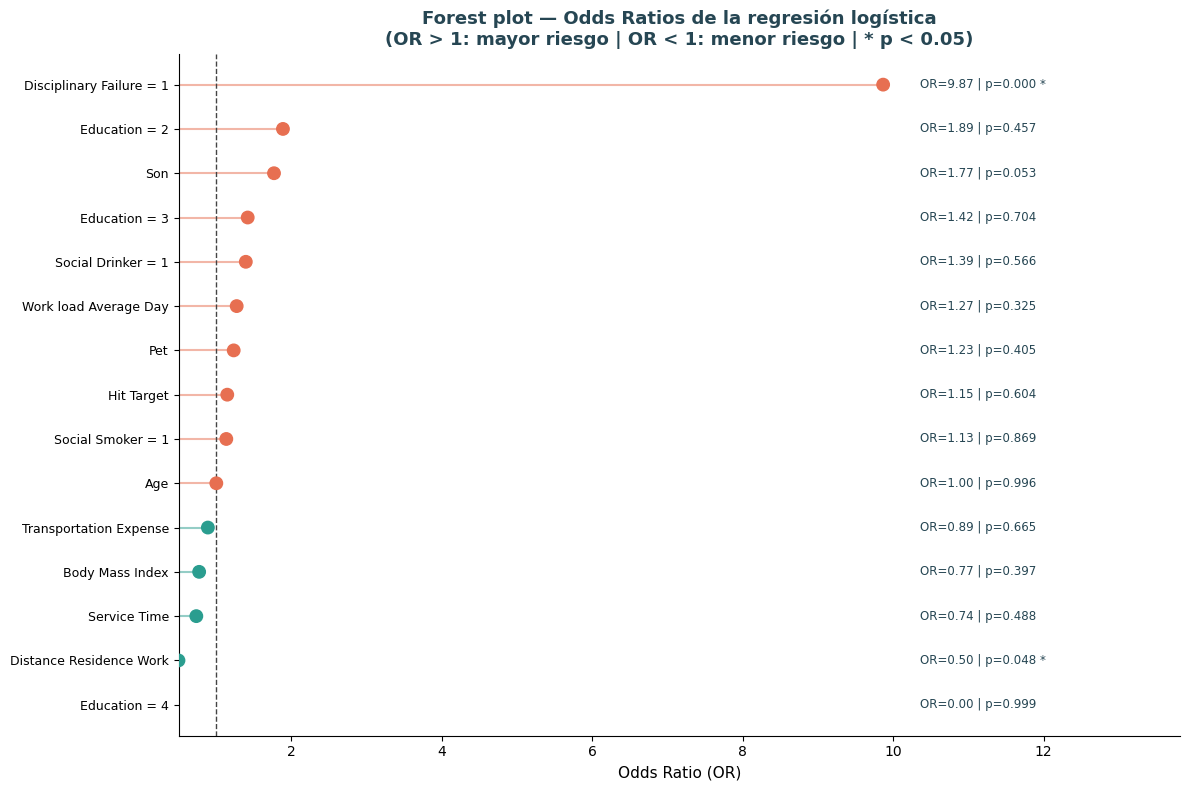

In [11]:
resultados_plot = resultados_logit.copy()
resultados_plot = resultados_plot.sort_values(
    'Odds_Ratio', ascending=True
)

color_pos = '#E76F51'   # OR > 1: mayor riesgo
color_neg = '#2A9D8F'   # OR < 1: menor riesgo
color_texto = '#264653'

colores = [
    color_pos if or_ > 1 else color_neg
    for or_ in resultados_plot['Odds_Ratio']
]

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    resultados_plot['Odds_Ratio'],
    range(len(resultados_plot)),
    color=colores, s=80, zorder=3
)

for i, (_, row) in enumerate(resultados_plot.iterrows()):
    ax.hlines(
        i, 0.5, row['Odds_Ratio'],
        color=colores[i], linewidth=1.5, alpha=0.5
    )
    sig_label = (
        ' *' if row['P_Value'] < 0.05 else ''
    )
    ax.text(
        max(resultados_plot['Odds_Ratio']) * 1.05,
        i,
        f"OR={row['Odds_Ratio']:.2f} | p={row['P_Value']:.3f}{sig_label}",
        va='center', fontsize=8.5, color=color_texto
    )

ax.axvline(1, color='#444444', linewidth=1, linestyle='--')
ax.set_yticks(range(len(resultados_plot)))
ax.set_yticklabels(
    resultados_plot['Variable_Limpia'], fontsize=9
)
ax.set_xlabel('Odds Ratio (OR)', fontsize=11)
ax.set_title(
    'Forest plot — Odds Ratios de la regresión logística\n'
    '(OR > 1: mayor riesgo | OR < 1: menor riesgo | * p < 0.05)',
    fontsize=13, fontweight='bold', color=color_texto
)
ax.set_xlim(0.5, max(resultados_plot['Odds_Ratio']) * 1.4)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
df_modelo["Distance_Rango"] = pd.qcut(
    df_modelo["Distance_Residence_Work"],
    q=4,
    duplicates="drop"
)

analisis_distancia = df_modelo.groupby("Distance_Rango").agg(
    empleados=("ID_Employee", "count"),
    media_horas=("Total_Horas_Absentismo", "mean"),
    mediana_horas=("Total_Horas_Absentismo", "median"),
    total_horas=("Total_Horas_Absentismo", "sum"),
    pct_absentismo_alto=("Absentismo_Alto", "mean")
).reset_index()

analisis_distancia["pct_absentismo_alto"] = analisis_distancia["pct_absentismo_alto"] * 100

analisis_distancia

C:\Users\vanes\AppData\Local\Temp\ipykernel_10280\1114916486.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analisis_distancia = df_modelo.groupby("Distance_Rango").agg(


,Distance_Rango,empleados,media_horas,mediana_horas,total_horas,pct_absentismo_alto
0,"(4.999, 15.0]",36,52.138889,8.0,1877,27.777778
1,"(15.0, 26.0]",44,41.613636,8.0,1831,27.272727
2,"(26.0, 37.5]",22,43.000000,8.0,946,27.272727
3,"(37.5, 52.0]",34,33.617647,4.0,1143,17.647059


## Visualizaciones

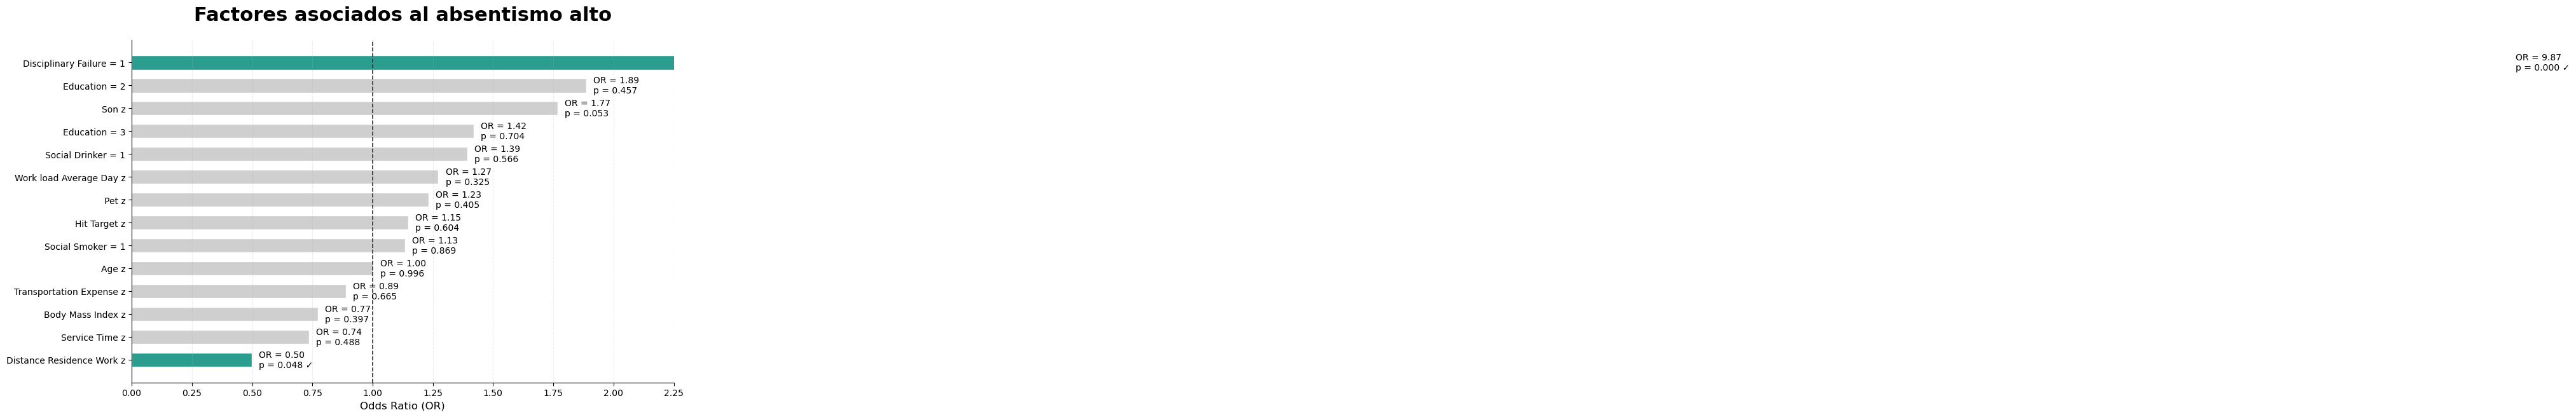

In [14]:
plot_df = resultados_logit.copy()

plot_df = plot_df[
    (~plot_df["Variable"].isin(["Intercept", "alpha"])) &
    (plot_df["Variable"] != "C(Education)[T.4]")
].copy()

plot_df["Variable"] = (
    plot_df["Variable"]
    .str.replace("C(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("[T.", " = ", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("_", " ", regex=False)
)

plot_df["Color"] = plot_df["P_Value"].apply(
    lambda x: "#2A9D8F" if x < 0.05 else "#CFCFCF"
)

plot_df = plot_df.sort_values("Odds_Ratio")

fig, ax = plt.subplots(figsize=(11,7))

bars = ax.barh(
    plot_df["Variable"],
    plot_df["Odds_Ratio"],
    color=plot_df["Color"],
    edgecolor="white",
    height=0.62
)

ax.axvline(
    1,
    color="#333333",
    linestyle="--",
    linewidth=1.2
)

for bar, (_, row) in zip(bars, plot_df.iterrows()):

    texto = f"OR = {row['Odds_Ratio']:.2f}\np = {row['P_Value']:.3f}"

    if row["P_Value"] < 0.05:
        texto += " ✓"

    ax.text(
        row["Odds_Ratio"] + 0.03,
        bar.get_y() + bar.get_height()/2,
        texto,
        va="center",
        fontsize=10
    )

ax.set_xlim(0, 2.25)

ax.set_xlabel(
    "Odds Ratio (OR)",
    fontsize=12
)

ax.set_ylabel("")

ax.set_title(
    "Factores asociados al absentismo alto",
    fontsize=22,
    weight="bold",
    pad=22
)

ax.text(
    0.5,
    1.02,
    "",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="dimgray"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

plt.show()

## 7. Interpretación de resultados

---



### Limitaciones




# RESUMEN

